![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

Run everytime you start to execute this Jupyter Notebook

In [1]:
import contextlib
import io
import warnings

import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

td.config.logging_level = "ERROR"
td.config.log_suppression = True

warnings.filterwarnings("ignore")
try:
    from loguru import logger
    logger.remove()
except Exception:
    pass

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


# Helper functions used in the parameter sweeps below. They keep the notebook
# shorter and avoid recalculating the same modal solutions several times.
def coupling_k(length_over_lpi):
    """Return the coupled power K from the normalized length L/Lpi."""
    return np.sin(0.5 * np.pi * np.asarray(length_over_lpi)) ** 2


def quiet_run(fn):
    """Run a callable while suppressing verbose library stdout/stderr."""
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        return fn()


def print_power_summary(label, model):
    """Print the final power, excess loss and output ratios of an EME model."""
    print(label)
    print(f"  Total OUT power = {model.tot_power_OUT:.4f}")
    print(f"  Excess loss = {model.EL:.4f} dB")
    print("  Power OUT =", [f"{p:.4f}" for p in model.power_OUT])
    print("  Ratio OUT =", [f"{r:.4f}" for r in model.ratio_OUT])


def lpi_from_neff_and_fraction_te(wavelength_um, neff, fraction_te):
    """Return Lpi for the first two TE-like and TM-like modes."""
    neff = np.asarray(neff)
    fraction_te = np.asarray(fraction_te)
    te_idx = np.where(fraction_te > 0.5)[0][:2]
    tm_idx = np.where(fraction_te < 0.5)[0][:2]
    out = {"TE": np.nan, "TM": np.nan, "TE_idx": te_idx, "TM_idx": tm_idx}
    if len(te_idx) >= 2:
        out["TE"] = 0.5 * wavelength_um / abs(neff[te_idx[0]].real - neff[te_idx[1]].real)
    if len(tm_idx) >= 2:
        out["TM"] = 0.5 * wavelength_um / abs(neff[tm_idx[0]].real - neff[tm_idx[1]].real)
    return out


# These caches only avoid recomputing repeated modal solutions during sweeps.
_dc_lpi_cache = {}
_mmi_lpi_cache = {}


def directional_coupler_lpi_te_tm(gap_um, slab_um, width_um=1.0, wavelength_um=1.55, num_modes=8):
    """Compute TE-like and TM-like Lpi values for a directional coupler."""
    key = (round(float(gap_um), 6), round(float(slab_um), 6), round(float(width_um), 6), round(float(wavelength_um), 6), int(num_modes))
    if key in _dc_lpi_cache:
        return _dc_lpi_cache[key]
    def compute():
        cs = gt.modes.WaveguideCoupler(
            wavelength=wavelength_um,
            core_width=(width_um, width_um),
            gap=gap_um,
            slab_thickness=slab_um,
            core_material="sin",
            clad_material="sio2",
            core_thickness=300 * nm,
            num_modes=num_modes,
            cache_path=".cache/",
            precision="double",
            max_grid_scaling=1.5,
            grid_resolution=20,
        )
        return lpi_from_neff_and_fraction_te(wavelength_um, cs.n_eff, cs.fraction_te)
    _dc_lpi_cache[key] = quiet_run(compute)
    return _dc_lpi_cache[key]


def mmi_body_lpi_te_tm(width_um, slab_um=0.0, wavelength_um=1.55, num_modes=16):
    """Compute TE-like and TM-like Lpi values for an MMI body section."""
    key = (round(float(width_um), 6), round(float(slab_um), 6), round(float(wavelength_um), 6), int(num_modes))
    if key in _mmi_lpi_cache:
        return _mmi_lpi_cache[key]
    def compute():
        wg = gt.modes.Waveguide(
            core_width=width_um,
            core_thickness=300 * nm,
            slab_thickness=slab_um,
            core_material="sin",
            clad_material="sio2",
            wavelength=wavelength_um,
            num_modes=num_modes,
            max_grid_scaling=1.5,
            grid_resolution=20,
            cache_path=".cache/",
            precision="double",
        )
        return lpi_from_neff_and_fraction_te(wavelength_um, wg.n_eff, wg.fraction_te)
    _mmi_lpi_cache[key] = quiet_run(compute)
    return _mmi_lpi_cache[key]


def relative_change(values):
    """Return the percentage change between the first and last sampled values."""
    values = np.asarray(values, dtype=float)
    return 100 * (values[-1] - values[0]) / values[0]


def imbalance_score(ratios, target):
    """Return the maximum absolute deviation from the desired output ratio."""
    ratios = np.asarray(ratios, dtype=float)
    return float(np.max(np.abs(ratios - target)))


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

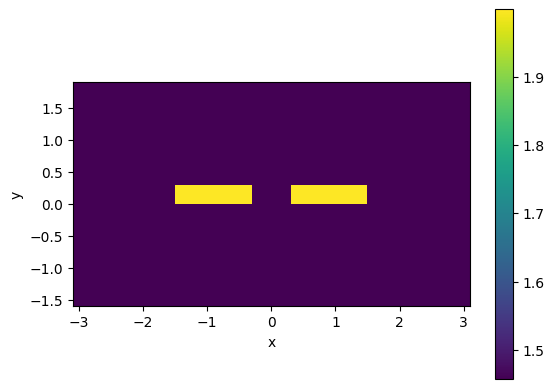

In [4]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [5]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [6]:
dcoupler_cs.fraction_te

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [7]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

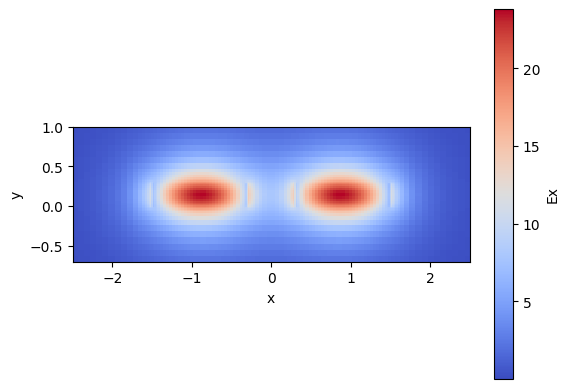

In [8]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

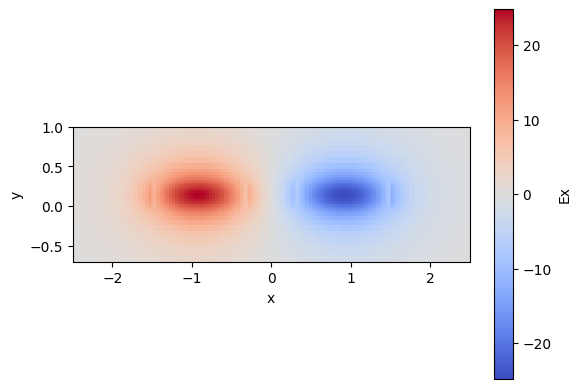

In [9]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

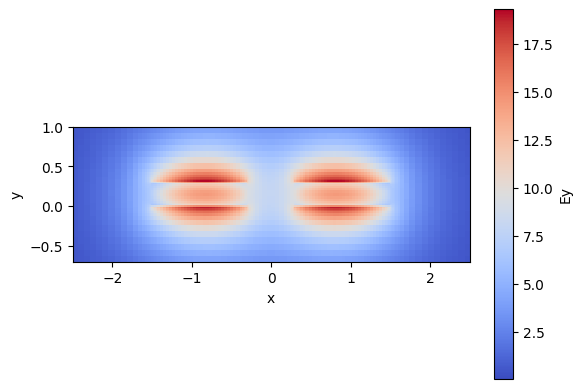

In [10]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

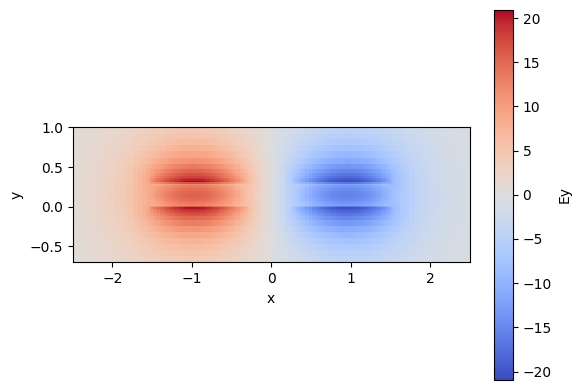

In [11]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [12]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

93.83767536701005
52.26022367744376


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [13]:
dcoupler_cs.coupling_length()

array([93.83767537, 52.26022368])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient \(K\). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

\[
K = \sin^2\left(rac{\pi L}{2L_\pi}ight)
\]

The plot below uses this expression directly. Two useful checks are: \(L/L_\pi = 0.5\) gives \(K=0.5\), so the device acts as a 50/50 splitter, while \(L/L_\pi = 1.0\) gives \(K=1\), corresponding to complete transfer to the adjacent guide.

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 \(\mu\mathrm{m}\) width and with a gap of 600 nm between them. 
- Plot the transfer function: \(K\) vs. \(L/L_\pi\).
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.


LO2 lambda = 1.50 um
L_pi_TE = 118.673 um
L_50/50 = 59.337 um
At L/L_pi = 0.5, K = 0.5 -> 50/50 splitter.
At L/L_pi = 1.0, K = 1.0 -> complete transfer to the adjacent waveguide.


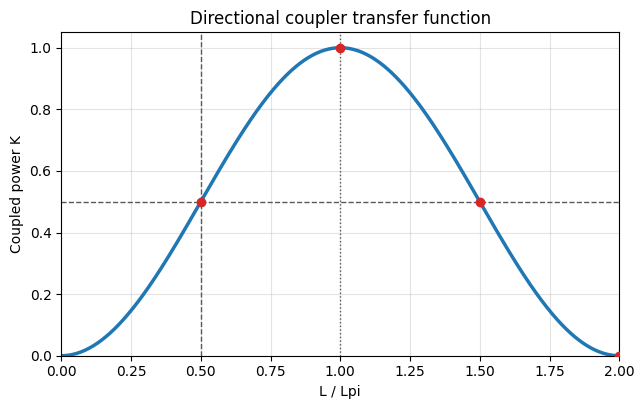

In [14]:
lambda_lo2 = 1.5
lo2_cs = gt.modes.WaveguideCoupler(
    wavelength=lambda_lo2,
    core_width=(1.2, 1.2),
    gap=0.6,
    slab_thickness=0 * nm,
    core_material="sin",
    clad_material="sio2",
    core_thickness=300 * nm,
    num_modes=4,
    cache_path=".cache/",
    precision="double",
    max_grid_scaling=1.5,
    grid_resolution=20,
)
lo2_neff = quiet_run(lambda: lo2_cs.n_eff)
L_pi_TE_LO2 = 0.5 * lambda_lo2 / abs(lo2_neff[0].real - lo2_neff[1].real)
L_50_LO2 = 0.5 * L_pi_TE_LO2

L_over_Lpi = np.linspace(0, 2, 401)
K = coupling_k(L_over_Lpi)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(L_over_Lpi, K, lw=2.5, color="tab:blue")
ax.scatter([0.5, 1.0, 1.5, 2.0], coupling_k([0.5, 1.0, 1.5, 2.0]), color="tab:red", zorder=3)
ax.axhline(0.5, color="0.35", ls="--", lw=1)
ax.axvline(0.5, color="0.35", ls="--", lw=1)
ax.axvline(1.0, color="0.35", ls=":", lw=1)
ax.set_xlabel("L / Lpi")
ax.set_ylabel("Coupled power K")
ax.set_title("Directional coupler transfer function")
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.35)

print(f"LO2 lambda = {lambda_lo2:.2f} um")
print(f"L_pi_TE = {L_pi_TE_LO2:.3f} um")
print(f"L_50/50 = {L_50_LO2:.3f} um")
print("At L/L_pi = 0.5, K = 0.5 -> 50/50 splitter.")
print("At L/L_pi = 1.0, K = 1.0 -> complete transfer to the adjacent waveguide.")

## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [15]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.wg_width = wg_width # Match the I/O waveguide mode to the simulated DC core width
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = abs(m.get_L_pi())
print(f"L_pi = {L_pi:.3f} um")
print(f"50/50 interaction length = {0.5 * L_pi:.3f} um")

L_pi = 94.027 um
50/50 interaction length = 47.014 um


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.2000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9689
Total OUT power: 0.9695
Excess loss [dB] =  0.1347
------------------------
Power over OUTs:  ['0.4847', '0.4847']
Ratio over OUTs ['0.5000', '0.5000']
2x2 DC, gap = 0.6 um
  Total OUT power = 0.9695
  Excess loss = 0.1347 dB
  Power OUT = ['0.4847', '0.4847']
  Ratio OUT = ['0.5000', '0.5000']


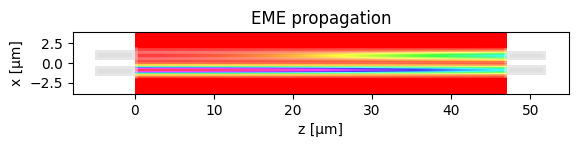

In [16]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5 * L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()
print_power_summary("2x2 DC, gap = 0.6 um", m)

Before sweeping the 2x2 directional coupler, the procedure is:

- Calculate \(L_\pi\) for each gap between 0.2 and 1.2 \(\mu\mathrm{m}\).
- Use \(L = L_\pi/2\) so each geometry is tested as a 50/50 splitter.
- Print the excess loss, total output power and output ratios to compare the candidates.


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/258 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/501 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/3189 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

gap [um] | L_pi [um] | L_50/50 [um] | EL [dB] | ratios
   0.20 |    25.814 |       12.907 |   1.087 | 0.4999/0.5001
   0.40 |    50.110 |       25.055 |   0.447 | 0.5001/0.4999
   0.60 |    94.027 |       47.013 |   0.135 | 0.5000/0.5000
   0.80 |   173.964 |       86.982 |   0.009 | 0.4999/0.5001
   1.00 |   318.884 |      159.442 |   0.149 | 0.4998/0.5002
   1.20 |   580.429 |      290.215 |   0.465 | 0.4998/0.5002


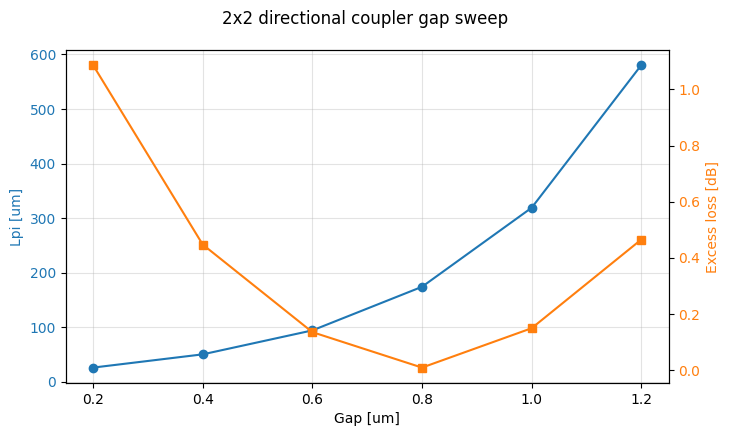

In [17]:
# LO.3 - Gap sweep for the 2x2 directional coupler.
dc_gap_values = np.arange(0.2, 1.2 + 1e-9, 0.2)
dc_gap_results = []

for gap in dc_gap_values:
    dc = DC_EME()
    dc.MMI_num_modes = 12
    dc.DC_wg_gap = float(gap)
    dc.DC_wg_width = 1.2
    dc.wg_width = 1.2
    dc.DC_N_waveguides = 2
    quiet_run(dc.find_all_modes)
    lpi = abs(dc.get_L_pi())
    dc.n_IN = 2
    dc.n_OUT = 2
    dc.L_MMI = 0.5 * lpi
    quiet_run(lambda: (dc.IO_overlap_1D(), dc.propagate(), dc.output_transfer()))
    dc_gap_results.append((gap, lpi, 0.5 * lpi, dc.EL, dc.tot_power_OUT, dc.ratio_OUT.copy()))

print("gap [um] | L_pi [um] | L_50/50 [um] | EL [dB] | ratios")
for gap, lpi, l50, el, total_power, ratios in dc_gap_results:
    print(f"{gap:7.2f} | {lpi:9.3f} | {l50:12.3f} | {el:7.3f} | {ratios[0]:.4f}/{ratios[1]:.4f}")

fig, ax1 = plt.subplots(figsize=(7.4, 4.4))
gaps = np.array([r[0] for r in dc_gap_results])
lpis = np.array([r[1] for r in dc_gap_results])
els = np.array([r[3] for r in dc_gap_results])
ax1.plot(gaps, lpis, marker="o", color="tab:blue", label="Lpi")
ax1.set_xlabel("Gap [um]")
ax1.set_ylabel("Lpi [um]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.35)
ax2 = ax1.twinx()
ax2.plot(gaps, els, marker="s", color="tab:orange", label="Excess loss")
ax2.set_ylabel("Excess loss [dB]", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
fig.suptitle("2x2 directional coupler gap sweep")
fig.tight_layout()

**LO3 conclusion.** The printed sweep shows that increasing the gap reduces evanescent overlap between the two guides, so \(L_\pi\) increases. Because each case is simulated with \(L=L_\pi/2\), the output ratios remain close to 50/50; the table and plot are used to compare the required footprint and excess loss for each gap.


## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient \(K < 0.01\). Assume a parallel interaction length of \(L=10\,\mathrm{mm}\) (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using \(w=1.0\,\mu\mathrm{m}\) and \(\lambda=1.55\,\mu\mathrm{m}\).

The first sampled points with \(K<0.01\) can correspond to periodic recurrences for exactly 10 mm, so they are not robust as a layout rule. For a conservative uncoupled-waveguide design, I require the coupling length to be long enough so that the waveguides remain weakly coupled over 10 mm instead of relying on one accidental minimum.


Required L_pi for conservative K < 0.01 over 10 mm: 156.8 mm
deep: first sampled K(10 mm)<0.01 at 1.4 um; conservative minimum gap = 4.0 um
shallow: first sampled K(10 mm)<0.01 at 0.4 um; conservative minimum gap = 5.0 um
We select the conservative gap because isolated K minima can be periodic recurrences, not truly uncoupled behavior.


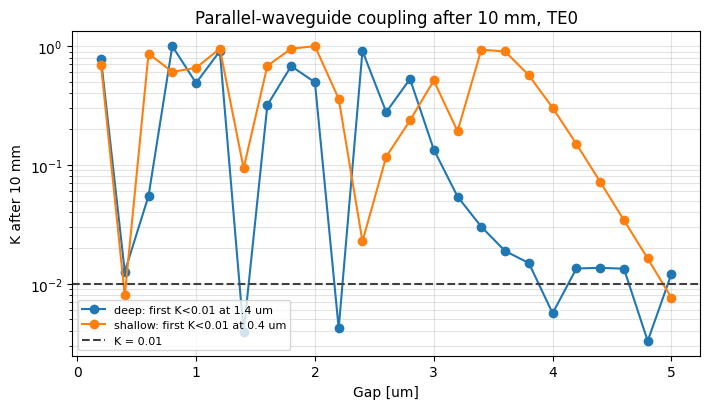

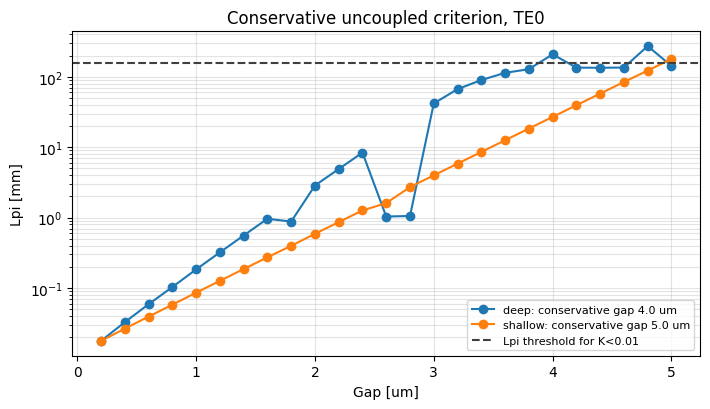

In [18]:
# LO.4 - Parallel uncoupled waveguides at L = 10 mm, TE0.
parallel_length_um = 10_000.0 # 10 mm
K_target = 0.01
# Invert K = sin^2(pi*L/(2*L_pi)) at K=0.01 to obtain the conservative L_pi threshold.
required_L_pi = np.pi * parallel_length_um / (2 * np.arcsin(np.sqrt(K_target)))
lo4_gap_values = np.arange(0.2, 5.0 + 1e-9, 0.2)
lo4_cases = {"deep": 0.0, "shallow": 150 * nm}
lo4_summary = {}

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for label, slab in lo4_cases.items():
    lpi = np.array([
        directional_coupler_lpi_te_tm(float(g), slab, width_um=1.0, wavelength_um=1.55)["TE"]
        for g in lo4_gap_values
    ])
    K_10mm = coupling_k(parallel_length_um / lpi)
    accidental_valid = np.where(K_10mm < K_target)[0]
    conservative_valid = np.where(lpi >= required_L_pi)[0]
    accidental_min_gap = lo4_gap_values[accidental_valid[0]] if len(accidental_valid) else np.nan
    conservative_min_gap = lo4_gap_values[conservative_valid[0]] if len(conservative_valid) else np.nan
    lo4_summary[label] = {
        "lpi": lpi,
        "K_10mm": K_10mm,
        "accidental_min_gap": accidental_min_gap,
        "conservative_min_gap": conservative_min_gap,
    }
    ax.semilogy(lo4_gap_values, K_10mm, marker="o", label=f"{label}: first K<0.01 at {accidental_min_gap:.1f} um")

ax.axhline(K_target, color="0.25", ls="--", label="K = 0.01")
ax.set_xlabel("Gap [um]")
ax.set_ylabel("K after 10 mm")
ax.set_title("Parallel-waveguide coupling after 10 mm, TE0")
ax.grid(True, which="both", alpha=0.35)
ax.legend(fontsize=8)
plt.tight_layout()

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for label, data in lo4_summary.items():
    ax.semilogy(lo4_gap_values, data["lpi"] / 1000, marker="o", label=f"{label}: conservative gap {data['conservative_min_gap']:.1f} um")
ax.axhline(required_L_pi / 1000, color="0.25", ls="--", label="Lpi threshold for K<0.01")
ax.set_xlabel("Gap [um]")
ax.set_ylabel("Lpi [mm]")
ax.set_title("Conservative uncoupled criterion, TE0")
ax.grid(True, which="both", alpha=0.35)
ax.legend(fontsize=8)
plt.tight_layout()

print(f"Required L_pi for conservative K < {K_target:.2f} over 10 mm: {required_L_pi/1000:.1f} mm")
for label, data in lo4_summary.items():
    print(
        f"{label}: first sampled K(10 mm)<0.01 at {data['accidental_min_gap']:.1f} um; "
        f"conservative minimum gap = {data['conservative_min_gap']:.1f} um"
    )
print("We select the conservative gap because isolated K minima can be periodic recurrences, not truly uncoupled behavior.")

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

[1.6786595 +7.78934672e-05j 1.67512732+7.81571827e-05j
 1.66922847+7.86028340e-05j 1.66094525+7.92401466e-05j
 1.65025312+8.00839409e-05j 1.63712124+8.11557006e-05j
 1.6215135 +8.24863265e-05j 1.60339058+8.41212350e-05j]


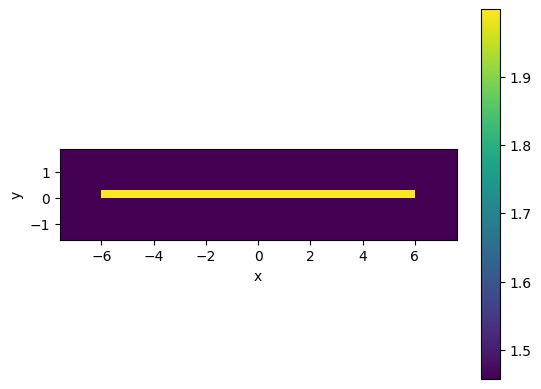

In [19]:
mmi_body_w = 12  
lambda_c = 1550 * nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.plot_index()
mmi_body_neff = mmi_body_waveguide.n_eff
mmi_body_fraction_te = mmi_body_waveguide.fraction_te
print(mmi_body_neff[:8])

In [20]:
mmi_body_waveguide.fraction_te

array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

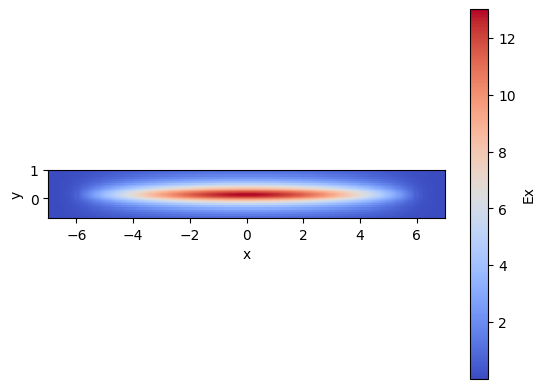

In [21]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

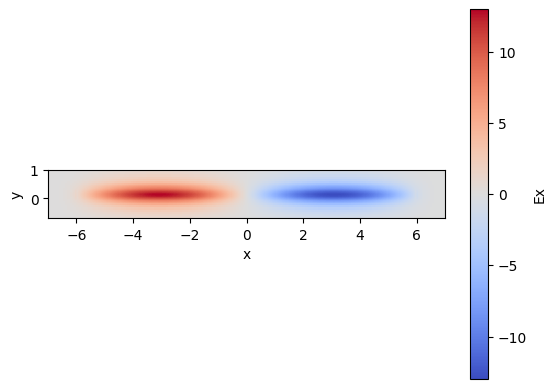

In [22]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

First TM-like mode index: 9


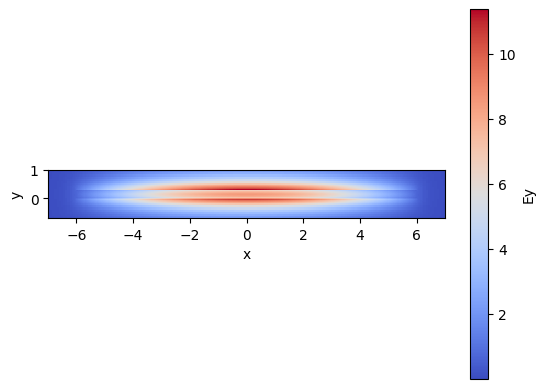

In [23]:
fraction_te = np.asarray(mmi_body_waveguide.fraction_te)
tm_idx_for_plot = np.where(fraction_te < 0.5)[0]
first_tm_mode = int(tm_idx_for_plot[0])
mmi_body_waveguide.plot_field(mode_index=first_tm_mode, field_name='Ey', value='real', cmap='coolwarm', xlim=(-7, 7), ylim=(-0.7, 1))
print(f"First TM-like mode index: {first_tm_mode}")

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [24]:
fraction_te = np.asarray(mmi_body_waveguide.fraction_te)
fraction_tm = 1 - fraction_te
neff = np.asarray(mmi_body_waveguide.n_eff)
te_idx = np.where(fraction_te > 0.5)[0][:2]
tm_idx = np.where(fraction_te < 0.5)[0][:2]

print("mode | pol | neff.real | frac_TE | frac_TM")
for idx in list(te_idx) + list(tm_idx):
    pol = "TE" if fraction_te[idx] > 0.5 else "TM"
    print(f"{idx:4d} | {pol:>2s} | {neff[idx].real:.6f} | {fraction_te[idx]:.4f} | {fraction_tm[idx]:.4f}")

L_pi_TE_MMI = 0.5 * lambda_c / abs(neff[te_idx[0]].real - neff[te_idx[1]].real)
L_pi_TM_MMI = 0.5 * lambda_c / abs(neff[tm_idx[0]].real - neff[tm_idx[1]].real)
print(f"MMI L_pi TE = {L_pi_TE_MMI:.3f} um")
print(f"MMI L_pi TM = {L_pi_TM_MMI:.3f} um")

lpi_te_tm_difference = 100 * abs(L_pi_TE_MMI - L_pi_TM_MMI) / L_pi_TE_MMI
te_modes_used = [int(i) for i in te_idx]
tm_modes_used = [int(i) for i in tm_idx]
print(f"TE-like modes used: {te_modes_used}")
print(f"TM-like modes used: {tm_modes_used}")
print(f"TE/TM L_pi difference = {lpi_te_tm_difference:.3f}%")
if lpi_te_tm_difference < 1.0:
    print("For this MMI width, TE and TM L_pi are nearly equal.")
else:
    print("For this MMI width, TE and TM L_pi are noticeably different.")

mode | pol | neff.real | frac_TE | frac_TM
   0 | TE | 1.678660 | 1.0000 | 0.0000
   1 | TE | 1.675127 | 1.0000 | 0.0000
   9 | TM | 1.577421 | 0.0002 | 0.9998
  10 | TM | 1.573889 | 0.0010 | 0.9990
MMI L_pi TE = 219.411 um
MMI L_pi TM = 219.480 um
TE-like modes used: [0, 1]
TM-like modes used: [9, 10]
TE/TM L_pi difference = 0.031%
For this MMI width, TE and TM L_pi are nearly equal.


**LO5 mode summary.** The TE-like modes are selected as the first two modes with \(\mathrm{fraction}_{TE}>0.5\), and the TM-like modes as the first two with \(\mathrm{fraction}_{TE}<0.5\). In both cases, \(L_\pi\) is obtained from the effective-index separation, \(L_\pi = \lambda/(2|n_{\mathrm{eff},0}-n_{\mathrm{eff},1}|)\). For the simulated MMI width, the printed TE and TM values are almost equal, so the body section is nearly polarization balanced in this specific modal comparison.


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [25]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = abs(m.get_L_pi())
print(f"L_pi = {L_pi:.3f} um")

L_pi = 69.036 um


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']
2x2 MMI baseline
  Total OUT power = 0.9075
  Excess loss = 0.4217 dB
  Power OUT = ['0.4675', '0.4399']
  Ratio OUT = ['0.5152', '0.4848']
Comparison with directional coupler:
  DC 50/50 length at gap = 0.6 um: 47.01 um
  MMI baseline length: 34.52 um
  The MMI is shorter here, but the baseline excess loss is higher before optimization.


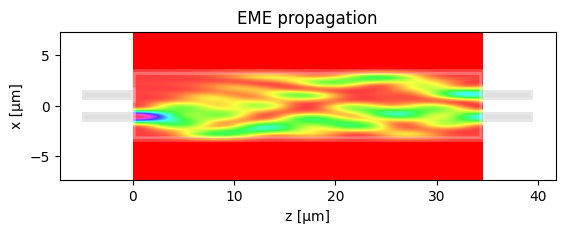

In [26]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width * np.array([-1/6, 1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width * np.array([-1/6, 1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2) * L_pi # STUDENT
m.dL_MMI = 0

# Run propagation
m.propagation()
print_power_summary("2x2 MMI baseline", m)

dc_l50_gap_06 = next(
    l50 for gap, _lpi, l50, _el, _total_power, _ratios in dc_gap_results
    if np.isclose(gap, 0.6)
)
print("Comparison with directional coupler:")
print(f"  DC 50/50 length at gap = 0.6 um: {dc_l50_gap_06:.2f} um")
print(f"  MMI baseline length: {m.L_MMI + m.dL_MMI:.2f} um")
print("  The MMI is shorter here, but the baseline excess loss is higher before optimization.")


### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

This manual optimization keeps the same body width and changes only two small design knobs. The parameter `dy` shifts the input/output guides laterally to tune the power balance between the two output ports. The correction `dL_MMI` slightly adjusts the phase accumulated in the multimode section, so it can recover a better split without changing the physical model.


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/674 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.8000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9559
Total OUT power: 0.9076
Excess loss [dB] =  0.4210
------------------------
Power over OUTs:  ['0.4541', '0.4535']
Ratio over OUTs ['0.5003', '0.4997']
2x2 MMI optimized positions/length
  Total OUT power = 0.9076
  Excess loss = 0.4210 dB
  Power OUT = ['0.4541', '0.4535']
  Ratio OUT = ['0.5003', '0.4997']


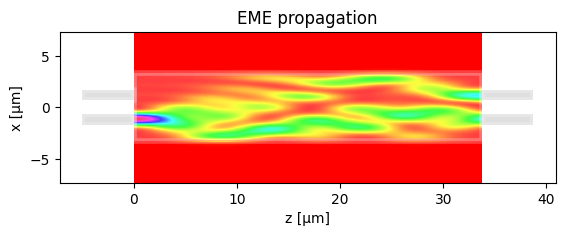

In [27]:
dy = 0.07
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width * np.array([-1/6, 1/6]) + np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width * np.array([-1/6, 1/6]) + np.array([-dy, dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.8  # STUDENT

# Run propagation
m.propagation()
print_power_summary("2x2 MMI optimized positions/length", m)

### LO.6.3 2x2 Multimode Interference Coupler - Optimization (II)

Here the I/O waveguides are widened while keeping the same MMI design logic. Increasing the I/O width improves the modal overlap with the multimode region, which can reduce excess loss. The final target check below verifies both the equal-split error and whether the excess-loss target is met.


In [28]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 1.0 # STUDENT. I/O width increment: 1.0 um -> total I/O width 2.0 um

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = abs(m.get_L_pi())
print(f"L_pi = {L_pi:.3f} um")
print(f"I/O waveguide width = {m.wg_width + m.wg_width_dw:.2f} um")

L_pi = 69.036 um
I/O waveguide width = 2.00 um


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/694 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.2000
IO wg width 1.0000
IO wg width increment 1.0000
------------------------
Total power IN coupled 0.9984
Total OUT power: 0.9924
Excess loss [dB] =  0.0332
------------------------
Power over OUTs:  ['0.4958', '0.4965']
Ratio over OUTs ['0.4996', '0.5004']
2x2 MMI wider I/O optimization
  Total OUT power = 0.9924
  Excess loss = 0.0332 dB
  Power OUT = ['0.4958', '0.4965']
  Ratio OUT = ['0.4996', '0.5004']
Target check:
  Equal split error = 0.0004
  Excess loss target met: True


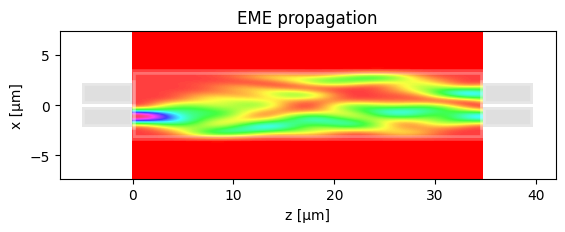

In [29]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = m.MMI_width * np.array([-1/6, 1/6]) + np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = m.MMI_width * np.array([-1/6, 1/6]) + np.array([-dy, dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2) * L_pi  # STUDENT
m.dL_MMI = 0.2 # STUDENT

# Run propagation
m.propagation()
print_power_summary("2x2 MMI wider I/O optimization", m)

print("Target check:")
print(f"  Equal split error = {abs(m.ratio_OUT[0] - 0.5):.4f}")
print(f"  Excess loss target met: {m.EL < 0.1}")


## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler.

The small sweep below tests a limited set of MMI widths, output-position scales and length corrections. The goal is to distribute the power close to 25% in each of the four outputs while reducing excess loss. The `score` is only a ranking metric used to sort candidates; it is not a new physical figure of merit.


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/231 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

...

  0%|          | 0/842 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/263 [00:00<?, ?it/s]

Top 5 candidate designs: score | EL | imbalance | W | scale | dL
0.2516 | 0.1895 | 0.0031 | 6.5 | 1.04 | 0.6
0.2584 | 0.1840 | 0.0037 | 6.5 | 1.02 | 0.6
0.3032 | 0.1796 | 0.0062 | 6.5 | 1.04 | 0.5
0.3180 | 0.2039 | 0.0057 | 6.5 | 1.00 | 0.6
0.3198 | 0.1796 | 0.0070 | 6.5 | 1.02 | 0.5
Selected 1x4 MMI width = 6.50 um
L_pi = 67.053 um
MMI length = 13.172 um
Output positions [um] = ['-2.535', '-0.845', '0.845', '2.535']
1x4 MMI selected design
  Total OUT power = 0.9573
  Excess loss = 0.1895 dB
  Power OUT = ['0.2365', '0.2422', '0.2423', '0.2364']
  Ratio OUT = ['0.2470', '0.2530', '0.2531', '0.2469']


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'EME propagation'}, xlabel='z [µm]', ylabel='x [µm]'>)

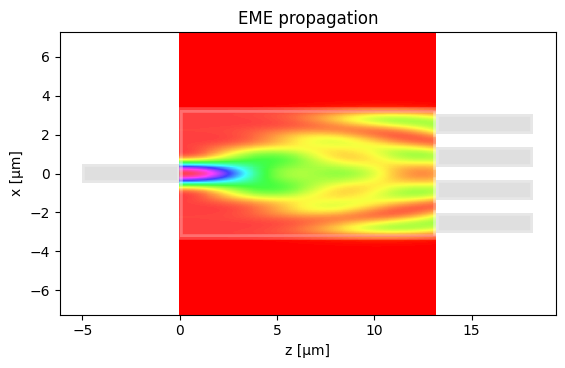

In [30]:
# LO.7 - 1x4 symmetric MMI coupler with a small optimization sweep.
# Design rule from the table: input at x = 0 and first 4-fold image at 3*L_pi/(4*N), N = 4.
def prepare_1x4_model(width, wg_width_dw=0.0, num_modes=30):
    model = MMI_EME()
    model.MMI_width = float(width)
    model.MMI_num_modes = num_modes
    model.wg_width_dw = float(wg_width_dw)
    quiet_run(model.find_all_modes)
    return model, abs(model.get_L_pi())

def evaluate_1x4_model(model, lpi, width, scale, dL):
    model.n_IN = 1
    model.n_OUT = 4
    model.IN_WVG_positions = [0.0]
    model.OUT_WVG_positions = list(float(width) * float(scale) * np.array([-3/8, -1/8, 1/8, 3/8]))
    model.L_MMI = 3 * lpi / 16
    model.dL_MMI = float(dL)
    quiet_run(lambda: (model.IO_overlap_1D(), model.propagate(), model.output_transfer()))
    return model

candidate_designs = []
prepared_1x4 = {}
for width in [6.5, 7.0, 7.5, 8.0, 10.0, 12.0]:
    prepared_1x4[width] = prepare_1x4_model(width)
    base_model, lpi = prepared_1x4[width]
    for scale in [0.98, 1.00, 1.02, 1.04]:
        for dL in [-1.0, -0.5, 0.0, 0.5, 0.6, 1.0]:
            model = evaluate_1x4_model(base_model, lpi, width, scale, dL)
            imbalance = imbalance_score(model.ratio_OUT, 0.25)
            # Ranking metric only: prioritize low excess loss and ratios close to 0.25.
            # This is not a physical figure of merit, only a practical way to sort candidates.
            score = model.EL + 20 * imbalance
            candidate_designs.append((score, model.EL, imbalance, width, scale, dL, lpi, model.tot_power_OUT, model.ratio_OUT.copy(), model.power_OUT.copy()))

candidate_designs.sort(key=lambda row: row[0])
best = candidate_designs[0]
_, lo7_EL, lo7_imbalance, mmi_1x4_width, output_position_scale, mmi_1x4_dL, L_pi_1x4, lo7_total_power, lo7_ratio, lo7_power = best
m_1x4_base, _ = prepared_1x4[mmi_1x4_width]
m_1x4 = evaluate_1x4_model(m_1x4_base, L_pi_1x4, mmi_1x4_width, output_position_scale, mmi_1x4_dL)

print("Top 5 candidate designs: score | EL | imbalance | W | scale | dL")
for row in candidate_designs[:5]:
    print(f"{row[0]:.4f} | {row[1]:.4f} | {row[2]:.4f} | {row[3]:.1f} | {row[4]:.2f} | {row[5]:.1f}")

print(f"Selected 1x4 MMI width = {mmi_1x4_width:.2f} um")
print(f"L_pi = {L_pi_1x4:.3f} um")
print(f"MMI length = {m_1x4.L_MMI + m_1x4.dL_MMI:.3f} um")
print("Output positions [um] =", [f"{x:.3f}" for x in m_1x4.OUT_WVG_positions])
print_power_summary("1x4 MMI selected design", m_1x4)

m_1x4.plot_propagation()

**LO7 selected design.** The executed sweep selects the lowest-score candidate printed above: \(W_{\mathrm{MMI}}=6.50\,\mu\mathrm{m}\), \(L_\pi=67.053\,\mu\mathrm{m}\), total MMI length \(13.172\,\mu\mathrm{m}\), and output positions \([-2.535, -0.845, 0.845, 2.535]~\mu\mathrm{m}\). The total output power is 0.9573, the excess loss is 0.1895 dB, and the four ratios are close to 25%: 0.2470, 0.2530, 0.2531 and 0.2469.


## Extra - Exercises

### E1. Directional coupler gap dependence

gap [um] | deep TE | deep TM | shallow TE | shallow TM
   0.20 |   17.69 |   16.72 |      17.71 |      18.56
   0.40 |   32.69 |   25.45 |      26.45 |      25.17
   0.60 |   58.77 |   38.43 |      39.25 |      33.86
   0.80 |  103.11 |   56.51 |      57.95 |      44.52
   1.00 |  183.51 |   85.35 |      85.76 |      58.19
   1.20 |  320.54 |  125.67 |     126.36 |      73.09
   1.40 |  556.78 |  183.82 |     185.87 |      89.01
   1.60 |  963.20 |  267.43 |     273.08 |     105.23
   1.80 |  878.42 |  344.28 |     397.70 |     127.20
   2.00 | 2855.03 |  558.73 |     588.23 |     839.94
   2.20 | 4898.71 |  803.36 |     862.79 |    1951.61
   2.40 | 8380.03 | 1151.93 |    1265.23 |  296487.19
Observation: Lpi increases rapidly with gap because evanescent overlap decreases.


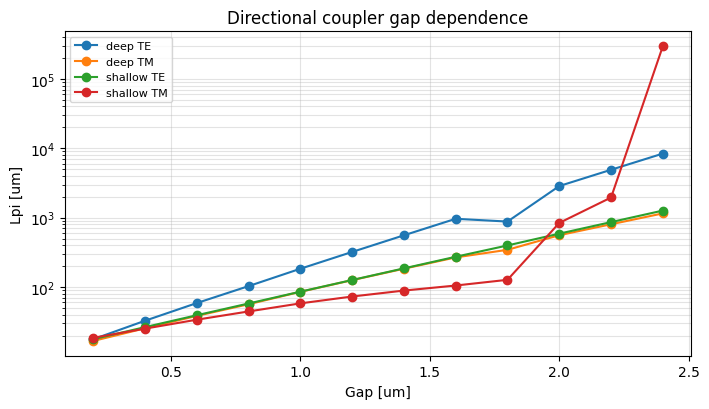

In [31]:
# E1. Directional coupler gap dependence for deep/shallow and TE/TM.
gap_values_E1 = np.arange(0.2, 2.4 + 1e-9, 0.2)
slab_cases = {"deep": 0.0, "shallow": 150 * nm}
E1 = {("deep", "TE"): [], ("deep", "TM"): [], ("shallow", "TE"): [], ("shallow", "TM"): []}

for slab_label, slab in slab_cases.items():
    for gap in gap_values_E1:
        values = directional_coupler_lpi_te_tm(float(gap), slab, width_um=1.0, wavelength_um=1.55)
        E1[(slab_label, "TE")].append(values["TE"])
        E1[(slab_label, "TM")].append(values["TM"])
for key in E1:
    E1[key] = np.array(E1[key], dtype=float)

plt.figure(figsize=(7.2, 4.2))
for (slab_label, pol), values in E1.items():
    plt.semilogy(gap_values_E1, values, marker="o", label=f"{slab_label} {pol}")
plt.xlabel("Gap [um]")
plt.ylabel("Lpi [um]")
plt.title("Directional coupler gap dependence")
plt.grid(True, which="both", alpha=0.35)
plt.legend(fontsize=8)
plt.tight_layout()

print("gap [um] | deep TE | deep TM | shallow TE | shallow TM")
for i, gap in enumerate(gap_values_E1):
    print(
        f"{gap:7.2f} | {E1[('deep','TE')][i]:7.2f} | {E1[('deep','TM')][i]:7.2f} | "
        f"{E1[('shallow','TE')][i]:10.2f} | {E1[('shallow','TM')][i]:10.2f}"
    )
print("Observation: Lpi increases rapidly with gap because evanescent overlap decreases.")

**Extra 1 conclusion.** \(L_\pi\) generally increases with gap because the evanescent overlap between waveguides decreases. The TE/TM and deep/shallow curves do not rise at the same rate, so the coupling length is both polarization-dependent and etch-dependent.


### E2. Directional coupler wavelength dependence

('deep', 'TE'): Lpi 73.26 -> 41.01 um, relative change -44.0%
('deep', 'TM'): Lpi 42.75 -> 32.05 um, relative change -25.0%
('shallow', 'TE'): Lpi 42.45 -> 33.06 um, relative change -22.1%
('shallow', 'TM'): Lpi 35.10 -> 31.51 um, relative change -10.2%


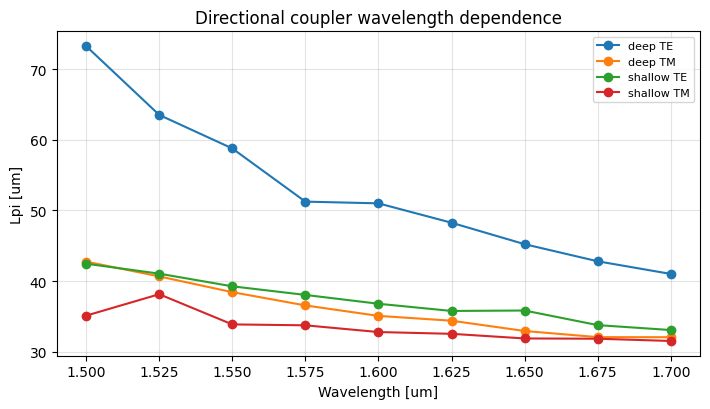

In [32]:
# E2. Directional coupler wavelength dependence for deep/shallow and TE/TM.
wavelength_values_E2 = np.linspace(1.5, 1.7, 9)
E2 = {("deep", "TE"): [], ("deep", "TM"): [], ("shallow", "TE"): [], ("shallow", "TM"): []}

for slab_label, slab in {"deep": 0.0, "shallow": 150 * nm}.items():
    for w in wavelength_values_E2:
        values = directional_coupler_lpi_te_tm(0.6, slab, width_um=1.0, wavelength_um=float(w))
        E2[(slab_label, "TE")].append(values["TE"])
        E2[(slab_label, "TM")].append(values["TM"])
for key in E2:
    E2[key] = np.array(E2[key], dtype=float)

plt.figure(figsize=(7.2, 4.2))
for (slab_label, pol), values in E2.items():
    plt.plot(wavelength_values_E2, values, marker="o", label=f"{slab_label} {pol}")
plt.xlabel("Wavelength [um]")
plt.ylabel("Lpi [um]")
plt.title("Directional coupler wavelength dependence")
plt.grid(True, alpha=0.35)
plt.legend(fontsize=8)
plt.tight_layout()

for key, values in E2.items():
    print(f"{key}: Lpi {values[0]:.2f} -> {values[-1]:.2f} um, relative change {relative_change(values):.1f}%")

**Extra 2 conclusion.** The directional coupler is spectrally sensitive: the printed relative changes show that \(L_\pi\) varies across the 1.5-1.7 \(\mu\mathrm{m}\) interval. In this sample, the deep TE case changes the most, while the shallow TM case is less sensitive.


### E3. MMI coupler wavelength dependence

MMI ('deep', 'TE'): Lpi 71.61 -> 63.37 um, relative change -11.5%
  Directional coupler same case: relative change -44.0%
MMI ('deep', 'TM'): Lpi 74.09 -> 68.18 um, relative change -8.0%
  Directional coupler same case: relative change -25.0%
MMI ('shallow', 'TE'): Lpi 76.22 -> 68.64 um, relative change -9.9%
  Directional coupler same case: relative change -22.1%
MMI ('shallow', 'TM'): Lpi 78.51 -> 72.90 um, relative change -7.1%
  Directional coupler same case: relative change -10.2%


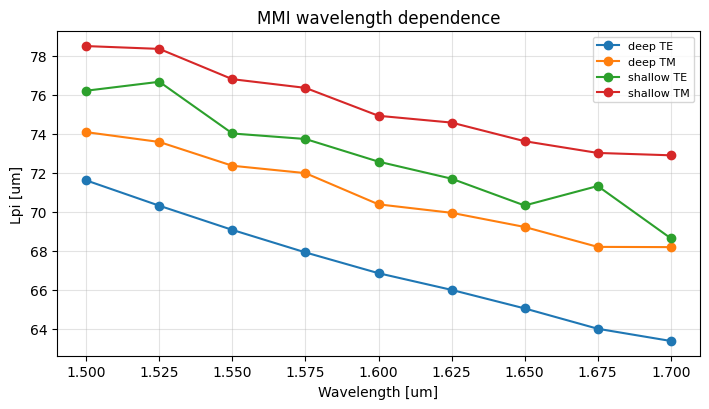

In [33]:
# E3. MMI coupler wavelength dependence for deep/shallow and TE/TM.
wavelength_values_E3 = np.linspace(1.5, 1.7, 9)
E3 = {("deep", "TE"): [], ("deep", "TM"): [], ("shallow", "TE"): [], ("shallow", "TM"): []}

for slab_label, slab in {"deep": 0.0, "shallow": 150 * nm}.items():
    for w in wavelength_values_E3:
        values = mmi_body_lpi_te_tm(6.6, slab_um=slab, wavelength_um=float(w), num_modes=16)
        E3[(slab_label, "TE")].append(values["TE"])
        E3[(slab_label, "TM")].append(values["TM"])
for key in E3:
    E3[key] = np.array(E3[key], dtype=float)

plt.figure(figsize=(7.2, 4.2))
for (slab_label, pol), values in E3.items():
    plt.plot(wavelength_values_E3, values, marker="o", label=f"{slab_label} {pol}")
plt.xlabel("Wavelength [um]")
plt.ylabel("Lpi [um]")
plt.title("MMI wavelength dependence")
plt.grid(True, alpha=0.35)
plt.legend(fontsize=8)
plt.tight_layout()

for key, values in E3.items():
    dc_change = relative_change(E2[key])
    mmi_change = relative_change(values)
    print(f"MMI {key}: Lpi {values[0]:.2f} -> {values[-1]:.2f} um, relative change {mmi_change:.1f}%")
    print(f"  Directional coupler same case: relative change {dc_change:.1f}%")

**Extra 3 conclusion.** The MMI body also changes with wavelength, but the printed relative changes are smaller than for the directional coupler in the same deep/shallow and TE/TM cases. This makes the MMI response less spectrally sensitive in this sampled comparison.


### E4. MMI coupler body width dependence

deep: closest sampled W = 10.0 um, TE/TM difference = 1.07%
shallow: closest sampled W = 10.0 um, TE/TM difference = 0.58%
Conclusion: no exact polarization-independent point was found in the sampled widths; deep and shallow only show approximate TE/TM convergence at their closest sampled points.


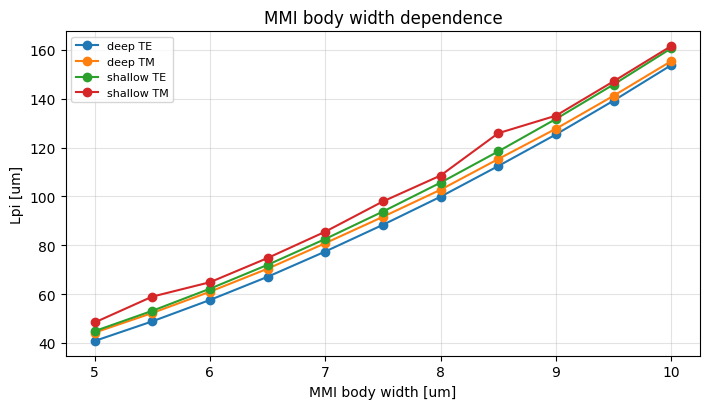

In [34]:
# E4. MMI coupler body width dependence for deep/shallow and TE/TM.
width_values_E4 = np.arange(5.0, 10.0 + 1e-9, 0.5)
E4 = {("deep", "TE"): [], ("deep", "TM"): [], ("shallow", "TE"): [], ("shallow", "TM"): []}

for slab_label, slab in {"deep": 0.0, "shallow": 150 * nm}.items():
    for width in width_values_E4:
        values = mmi_body_lpi_te_tm(float(width), slab_um=slab, wavelength_um=1.55, num_modes=16)
        E4[(slab_label, "TE")].append(values["TE"])
        E4[(slab_label, "TM")].append(values["TM"])
for key in E4:
    E4[key] = np.array(E4[key], dtype=float)

plt.figure(figsize=(7.2, 4.2))
for (slab_label, pol), values in E4.items():
    plt.plot(width_values_E4, values, marker="o", label=f"{slab_label} {pol}")
plt.xlabel("MMI body width [um]")
plt.ylabel("Lpi [um]")
plt.title("MMI body width dependence")
plt.grid(True, alpha=0.35)
plt.legend(fontsize=8)
plt.tight_layout()

E4_best = {}
for slab_label in ["deep", "shallow"]:
    te = E4[(slab_label, "TE")]
    tm = E4[(slab_label, "TM")]
    diff = np.abs(te - tm) / te
    best_idx = int(np.nanargmin(diff))
    E4_best[slab_label] = (width_values_E4[best_idx], 100 * diff[best_idx])
    print(f"{slab_label}: closest sampled W = {width_values_E4[best_idx]:.1f} um, TE/TM difference = {100*diff[best_idx]:.2f}%")

print("Conclusion: no exact polarization-independent point was found in the sampled widths; deep and shallow only show approximate TE/TM convergence at their closest sampled points.")

**Extra 4 conclusion.** The width sweep finds only approximate TE/TM convergence in the sampled points, not an exact polarization-independent design. Since the closest points occur at the edge of this coarse sweep, a finer and wider scan would be needed before claiming a robust polarization-independent width.


# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points